# Sentiment analysis of the ParlaMint-SI dataset

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('../../Datasets/Sentiment_Analysis/ParlaMint-SI.tsv', delimiter='\t', encoding='utf-8')
df.head()

,ID,sent_id,text,text_en,sent_annotations,utt_annotations,labels,sentiment,Title,Date,...,Speaker_MP,Speaker_minister,Speaker_party,Speaker_party_name,Party_status,Party_orientation,Speaker_ID,Speaker_name,Speaker_gender,Speaker_birth
0,ParlaMint-SI_2022-04-06-SDZ8-Izredna-99.ana.u1,ParlaMint-SI_2022-04-06-SDZ8-Izredna-99.ana.se...,Spoštovane kolegice poslanke in kolegi poslanc...,"Dear fellow Members and fellow Members, ladies...",4.052144,2.42,Neutral Negative,Neutral,Minutes of the National Assembly of the Republ...,2022-04-06,...,MP,notMinister,DeSUS,Demokratična stranka upokojencev Slovenije,Coalition,Centre to centre-left,SimonovičBranko,"Simonovič, Branko",M,1953
1,ParlaMint-SI_2022-04-06-SDZ8-Izredna-99.ana.u1,ParlaMint-SI_2022-04-06-SDZ8-Izredna-99.ana.se...,Začenjam z nadaljevanjem 99. izredne seje Drža...,I'm starting with the 99th Extraordinary Meeti...,3.223034,2.42,Neutral Negative,Neutral,Minutes of the National Assembly of the Republ...,2022-04-06,...,MP,notMinister,DeSUS,Demokratična stranka upokojencev Slovenije,Coalition,Centre to centre-left,SimonovičBranko,"Simonovič, Branko",M,1953
2,ParlaMint-SI_2022-04-06-SDZ8-Izredna-99.ana.u1,ParlaMint-SI_2022-04-06-SDZ8-Izredna-99.ana.se...,"Obveščen sem, da se današnje seje ne morejo ud...",I am informed that today's meeting cannot be a...,1.778516,2.42,Neutral Negative,Neutral,Minutes of the National Assembly of the Republ...,2022-04-06,...,MP,notMinister,DeSUS,Demokratična stranka upokojencev Slovenije,Coalition,Centre to centre-left,SimonovičBranko,"Simonovič, Branko",M,1953
3,ParlaMint-SI_2022-04-06-SDZ8-Izredna-99.ana.u1,ParlaMint-SI_2022-04-06-SDZ8-Izredna-99.ana.se...,Vse prisotne lepo pozdravljam!,I say hello to everyone who's here!,4.814360,2.42,Neutral Negative,Neutral,Minutes of the National Assembly of the Republ...,2022-04-06,...,MP,notMinister,DeSUS,Demokratična stranka upokojencev Slovenije,Coalition,Centre to centre-left,SimonovičBranko,"Simonovič, Branko",M,1953
4,ParlaMint-SI_2022-04-06-SDZ8-Izredna-99.ana.u1,ParlaMint-SI_2022-04-06-SDZ8-Izredna-99.ana.se...,Prehajamo na 10.,We're moving on to 10.,3.219104,2.42,Neutral Negative,Neutral,Minutes of the National Assembly of the Republ...,2022-04-06,...,MP,notMinister,DeSUS,Demokratična stranka upokojencev Slovenije,Coalition,Centre to centre-left,SimonovičBranko,"Simonovič, Branko",M,1953


In [2]:
utt = df.drop_duplicates(subset=['ID']).reset_index(drop=True)
utt.head()

,ID,sent_id,text,text_en,sent_annotations,utt_annotations,labels,sentiment,Title,Date,...,Speaker_MP,Speaker_minister,Speaker_party,Speaker_party_name,Party_status,Party_orientation,Speaker_ID,Speaker_name,Speaker_gender,Speaker_birth
0,ParlaMint-SI_2022-04-06-SDZ8-Izredna-99.ana.u1,ParlaMint-SI_2022-04-06-SDZ8-Izredna-99.ana.se...,Spoštovane kolegice poslanke in kolegi poslanc...,"Dear fellow Members and fellow Members, ladies...",4.052144,2.42,Neutral Negative,Neutral,Minutes of the National Assembly of the Republ...,2022-04-06,...,MP,notMinister,DeSUS,Demokratična stranka upokojencev Slovenije,Coalition,Centre to centre-left,SimonovičBranko,"Simonovič, Branko",M,1953
1,ParlaMint-SI_2022-04-06-SDZ8-Izredna-99.ana.u2,ParlaMint-SI_2022-04-06-SDZ8-Izredna-99.ana.se...,"Spoštovane kolegice in kolegi, gospe in gospodje!","Dear colleagues, ladies and gentlemen!",3.846659,3.88,Mixed Positive,Positive,Minutes of the National Assembly of the Republ...,2022-04-06,...,MP,notMinister,NP,Poslanska skupina nepovezanih poslancev,-,-,ZorčičIgor,"Zorčič, Igor",M,1978
2,ParlaMint-SI_2022-04-06-SDZ8-Izredna-99.ana.u3,ParlaMint-SI_2022-04-06-SDZ8-Izredna-99.ana.se...,Hvala tudi vam.,"Thank you, too.",4.758979,3.00,Neutral Positive,Neutral,Minutes of the National Assembly of the Republ...,2022-04-06,...,MP,notMinister,DeSUS,Demokratična stranka upokojencev Slovenije,Coalition,Centre to centre-left,SimonovičBranko,"Simonovič, Branko",M,1953
3,ParlaMint-SI_2022-04-06-SDZ8-Izredna-99.ana.u4,ParlaMint-SI_2022-04-06-SDZ8-Izredna-99.ana.se...,"Hvala lepa, predsedujoči.","Thank you very much, Chairman.",4.019485,3.19,Neutral Positive,Neutral,Minutes of the National Assembly of the Republ...,2022-04-06,...,notMP,notMinister,-,-,-,-,SlavinecMitja,"Slavinec, Mitja",M,1964
4,ParlaMint-SI_2022-04-06-SDZ8-Izredna-99.ana.u5,ParlaMint-SI_2022-04-06-SDZ8-Izredna-99.ana.se...,Hvala tudi vam.,"Thank you, too.",4.758979,3.00,Neutral Positive,Neutral,Minutes of the National Assembly of the Republ...,2022-04-06,...,MP,notMinister,DeSUS,Demokratična stranka upokojencev Slovenije,Coalition,Centre to centre-left,SimonovičBranko,"Simonovič, Branko",M,1953


In [3]:
utt['Term'] = utt['Term'].replace({
    '3. mandat': 'Term 3',
    '4. mandat': 'Term 4',
    '5. mandat': 'Term 5',
    '6. mandat': 'Term 6',
    '7. mandat': 'Term 7',
    '8. mandat': 'Term 8'
})
utt['Year'] = utt['Date'].str.split('-').str[0]

mismatch = utt[utt['Year'] == '2012']
update = mismatch.index
utt.loc[update, 'Term'] = 'Term 6'

terms_check = utt[utt['Term'] == 'Term 5']
print("Earliest Term5 speech: ", terms_check['Date'].min())
print("Last Term5 speech: ", terms_check['Date'].max())

utt

Earliest Term5 speech:  2008-10-15
Last Term5 speech:  2011-12-08


,ID,sent_id,text,text_en,sent_annotations,utt_annotations,labels,sentiment,Title,Date,...,Speaker_minister,Speaker_party,Speaker_party_name,Party_status,Party_orientation,Speaker_ID,Speaker_name,Speaker_gender,Speaker_birth,Year
0,ParlaMint-SI_2022-04-06-SDZ8-Izredna-99.ana.u1,ParlaMint-SI_2022-04-06-SDZ8-Izredna-99.ana.se...,Spoštovane kolegice poslanke in kolegi poslanc...,"Dear fellow Members and fellow Members, ladies...",4.052144,2.42,Neutral Negative,Neutral,Minutes of the National Assembly of the Republ...,2022-04-06,...,notMinister,DeSUS,Demokratična stranka upokojencev Slovenije,Coalition,Centre to centre-left,SimonovičBranko,"Simonovič, Branko",M,1953,2022
1,ParlaMint-SI_2022-04-06-SDZ8-Izredna-99.ana.u2,ParlaMint-SI_2022-04-06-SDZ8-Izredna-99.ana.se...,"Spoštovane kolegice in kolegi, gospe in gospodje!","Dear colleagues, ladies and gentlemen!",3.846659,3.88,Mixed Positive,Positive,Minutes of the National Assembly of the Republ...,2022-04-06,...,notMinister,NP,Poslanska skupina nepovezanih poslancev,-,-,ZorčičIgor,"Zorčič, Igor",M,1978,2022
2,ParlaMint-SI_2022-04-06-SDZ8-Izredna-99.ana.u3,ParlaMint-SI_2022-04-06-SDZ8-Izredna-99.ana.se...,Hvala tudi vam.,"Thank you, too.",4.758979,3.00,Neutral Positive,Neutral,Minutes of the National Assembly of the Republ...,2022-04-06,...,notMinister,DeSUS,Demokratična stranka upokojencev Slovenije,Coalition,Centre to centre-left,SimonovičBranko,"Simonovič, Branko",M,1953,2022
3,ParlaMint-SI_2022-04-06-SDZ8-Izredna-99.ana.u4,ParlaMint-SI_2022-04-06-SDZ8-Izredna-99.ana.se...,"Hvala lepa, predsedujoči.","Thank you very much, Chairman.",4.019485,3.19,Neutral Positive,Neutral,Minutes of the National Assembly of the Republ...,2022-04-06,...,notMinister,-,-,-,-,SlavinecMitja,"Slavinec, Mitja",M,1964,2022
4,ParlaMint-SI_2022-04-06-SDZ8-Izredna-99.ana.u5,ParlaMint-SI_2022-04-06-SDZ8-Izredna-99.ana.se...,Hvala tudi vam.,"Thank you, too.",4.758979,3.00,Neutral Positive,Neutral,Minutes of the National Assembly of the Republ...,2022-04-06,...,notMinister,DeSUS,Demokratična stranka upokojencev Slovenije,Coalition,Centre to centre-left,SimonovičBranko,"Simonovič, Branko",M,1953,2022
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
311342,ParlaMint-SI_2005-01-24-SDZ4-Redna-02.ana.u242,ParlaMint-SI_2005-01-24-SDZ4-Redna-02.ana.seg5...,Hvala.,Thank you.,4.510695,2.99,Neutral Positive,Neutral,Minutes of the National Assembly of the Republ...,2005-01-24,...,notMinister,DeSUS,Demokratična stranka upokojencev Slovenije,Coalition,Centre to centre-left,KlavoraVasja,"Klavora, Vasja",M,1936,2005
311343,ParlaMint-SI_2005-01-24-SDZ4-Redna-02.ana.u243,ParlaMint-SI_2005-01-24-SDZ4-Redna-02.ana.seg5...,"Dodatno vprašanje je pa seveda povezano s tem,...","However, the additional issue is, of course, l...",2.585003,2.75,Neutral Positive,Neutral,Minutes of the National Assembly of the Republ...,2005-01-24,...,notMinister,LDS,Liberalna demokracija Slovenije,Opposition,Centre to centre-left,CviklMilanMartin,"Cvikl, Milan Martin",M,1959,2005
311344,ParlaMint-SI_2005-01-24-SDZ4-Redna-02.ana.u244,ParlaMint-SI_2005-01-24-SDZ4-Redna-02.ana.seg5...,Hvala lepa.,Thank you very much.,4.084590,3.02,Neutral Positive,Neutral,Minutes of the National Assembly of the Republ...,2005-01-24,...,notMinister,DeSUS,Demokratična stranka upokojencev Slovenije,Coalition,Centre to centre-left,KlavoraVasja,"Klavora, Vasja",M,1936,2005
311345,ParlaMint-SI_2005-01-24-SDZ4-Redna-02.ana.u245,ParlaMint-SI_2005-01-24-SDZ4-Redna-02.ana.seg5...,Hvala lepa.,Thank you very much.,4.084590,1.01,Mixed Negative,Negative,Minutes of the National Assembly of the Republ...,2005-01-24,...,notMinister,NSi,Nova Slovenija – Krščanski demokrati,Coalition,Centre-right,BajukAndrej,"Bajuk, Andrej",M,1943,2005


## Descriptive statistics

Checking distributions within the new ParlaMint-SI corpus and the characteristics of the political parties within

Corpus: 
- Total no. of speeches
- % of procedural speeches within the corpus (remove from the analysis)
- label distribution
- sentiment distribution overall (count, %)
- sentiment distribution across terms (count, %)
- sentiment distribution across political orientation (count, %)
- sentiment distribution across political status (coalition/opposition, (count, %))


In [4]:
utt_filter = utt[utt['Speaker_role'] == 'Regular']
utt_filter.head()

,ID,sent_id,text,text_en,sent_annotations,utt_annotations,labels,sentiment,Title,Date,...,Speaker_minister,Speaker_party,Speaker_party_name,Party_status,Party_orientation,Speaker_ID,Speaker_name,Speaker_gender,Speaker_birth,Year
1,ParlaMint-SI_2022-04-06-SDZ8-Izredna-99.ana.u2,ParlaMint-SI_2022-04-06-SDZ8-Izredna-99.ana.se...,"Spoštovane kolegice in kolegi, gospe in gospodje!","Dear colleagues, ladies and gentlemen!",3.846659,3.88,Mixed Positive,Positive,Minutes of the National Assembly of the Republ...,2022-04-06,...,notMinister,NP,Poslanska skupina nepovezanih poslancev,-,-,ZorčičIgor,"Zorčič, Igor",M,1978,2022
3,ParlaMint-SI_2022-04-06-SDZ8-Izredna-99.ana.u4,ParlaMint-SI_2022-04-06-SDZ8-Izredna-99.ana.se...,"Hvala lepa, predsedujoči.","Thank you very much, Chairman.",4.019485,3.19,Neutral Positive,Neutral,Minutes of the National Assembly of the Republ...,2022-04-06,...,notMinister,-,-,-,-,SlavinecMitja,"Slavinec, Mitja",M,1964,2022
5,ParlaMint-SI_2022-04-06-SDZ8-Izredna-99.ana.u6,ParlaMint-SI_2022-04-06-SDZ8-Izredna-99.ana.se...,"Spoštovani, hvala za besedo.","Your Honor, thank you for your word.",3.833185,4.38,Mixed Positive,Positive,Minutes of the National Assembly of the Republ...,2022-04-06,...,notMinister,SAB,Stranka Alenke Bratušek,Opposition,Centre-left,BandelliMarko,"Bandelli, Marko",M,1967,2022
7,ParlaMint-SI_2022-04-06-SDZ8-Izredna-99.ana.u8,ParlaMint-SI_2022-04-06-SDZ8-Izredna-99.ana.se...,"Hvala za besedo, podpredsednik.","Thank you for your word, Vice President.",3.653113,3.94,Mixed Positive,Positive,Minutes of the National Assembly of the Republ...,2022-04-06,...,notMinister,Konkretno,Konkretno,Coalition,Centre,ŽnidaričMojca,"Žnidarič, Mojca",F,1977,2022
9,ParlaMint-SI_2022-04-06-SDZ8-Izredna-99.ana.u10,ParlaMint-SI_2022-04-06-SDZ8-Izredna-99.ana.se...,Lep pozdrav!,Good-bye!,4.872236,4.92,Positive,Positive,Minutes of the National Assembly of the Republ...,2022-04-06,...,notMinister,SNS,Slovenska nacionalna stranka,Opposition,Right to far-right,ŠiškoDušan,"Šiško, Dušan",M,1969,2022


In [5]:
utt_procedural = utt[utt['Speaker_role'] != 'Regular']


utt_labels = utt_filter['labels'].value_counts()
utt_sentiment = utt_filter['sentiment'].value_counts()

percent_procedural = (len(utt_procedural) / len(utt)) * 100
percent_lables = (utt_labels / len(utt_filter)) * 100
percent_sent = (utt_sentiment / len(utt_filter)) * 100

print("Total no. of speeches: ", len(utt_filter))
print("Total no. of procedural speeches: ", len(utt_procedural), "%: ", percent_procedural)
print("Earliest speech: ", utt['Date'].min())
print("Last speech: ", utt['Date'].max())
print("Distribution of the labels: ", percent_lables)
print("Distribution of the sentiment: ", percent_sent)

Total no. of speeches:  153763
Total no. of procedural speeches:  157584 %:  50.613624027210804
Earliest speech:  2000-10-27
Last speech:  2022-04-06
Distribution of the labels:  labels
Negative            42.146030
Mixed Negative      17.854750
Neutral Negative    14.145796
Neutral Positive    13.048002
Mixed Positive       9.593986
Positive             3.211436
Name: count, dtype: float64
Distribution of the sentiment:  sentiment
Negative    60.000780
Neutral     27.193798
Positive    12.805421
Name: count, dtype: float64


In [6]:
parties = utt_filter['Speaker_party'].value_counts()
orientations = utt_filter['Party_orientation'].value_counts()
status = utt_filter['Party_status'].value_counts()

percent_parties = (parties / len(utt_filter)) * 100
percent_orientations = (orientations / len(utt_filter)) * 100
percent_staus = (status / len(utt_filter)) * 100

print("% of speeches per political party:", percent_parties)
print("% of speeches for coalition/opposition: ", percent_staus)

% of speeches per political party: Speaker_party
SDS          22.746044
-            12.466588
SD           10.836807
LDS           9.169956
NSi           8.687396
SNS           5.139078
SLS           4.690985
DeSUS         4.417187
SMC           3.906011
Levica        3.122988
ZLSD          2.340615
PS            2.073971
LMŠ           1.827488
Zares         1.814481
ZL            1.582956
SAB           1.271437
NP            1.097793
DL            0.684820
NeP           0.534589
SLS+SKD       0.526134
SMS           0.458498
Lipa          0.256889
ZaAB          0.212015
Konkretno     0.074790
DLGV          0.060483
Name: count, dtype: float64
% of speeches for coalition/opposition:  Party_status
Opposition    44.975709
Coalition     36.848917
-             18.175374
Name: count, dtype: float64


In [7]:
print("% of speeches per political orientation:", percent_orientations)

% of speeches per political orientation: Party_orientation
Right                     22.806527
Centre to centre-left     21.394614
Centre-left               16.933853
-                         14.355859
Centre-right              13.904515
Right to far-right         5.139078
Left                       4.705944
Centre to centre-right     0.684820
Centre                     0.074790
Name: count, dtype: float64


In [8]:
orientation_count = utt_filter['Party_orientation'].value_counts()
orientation_check = utt_filter[['Party_orientation', 'Speaker_party']]
orientation_check = orientation_check.groupby('Party_orientation')['Speaker_party'].value_counts()

print(orientation_count)
print(orientation_check)


Party_orientation
Right                     35068
Centre to centre-left     32897
Centre-left               26038
-                         22074
Centre-right              21380
Right to far-right         7902
Left                       7236
Centre to centre-right     1053
Centre                      115
Name: count, dtype: int64
Party_orientation       Speaker_party
-                       -                19169
                        NP                1688
                        NeP                822
                        Lipa               395
Centre                  Konkretno          115
Centre to centre-left   LDS              14100
                        DeSUS             6792
                        SMC               6006
                        PS                3189
                        LMŠ               2810
Centre to centre-right  DL                1053
Centre-left             SD               16663
                        ZLSD              3599
                   

In [9]:
term_activity = utt_filter.groupby(['Term', 'Speaker_party']).size().reset_index(name='utt_count')
term_activity = term_activity[~term_activity['Speaker_party'].isin(["-", "NeP", "NP", "Lipa", "Konkretno"])]
term_activity.head()

,Term,Speaker_party,utt_count
1,Term 3,DeSUS,666
2,Term 3,LDS,6036
3,Term 3,NSi,4375
5,Term 3,SDS,5330
6,Term 3,SLS,1719


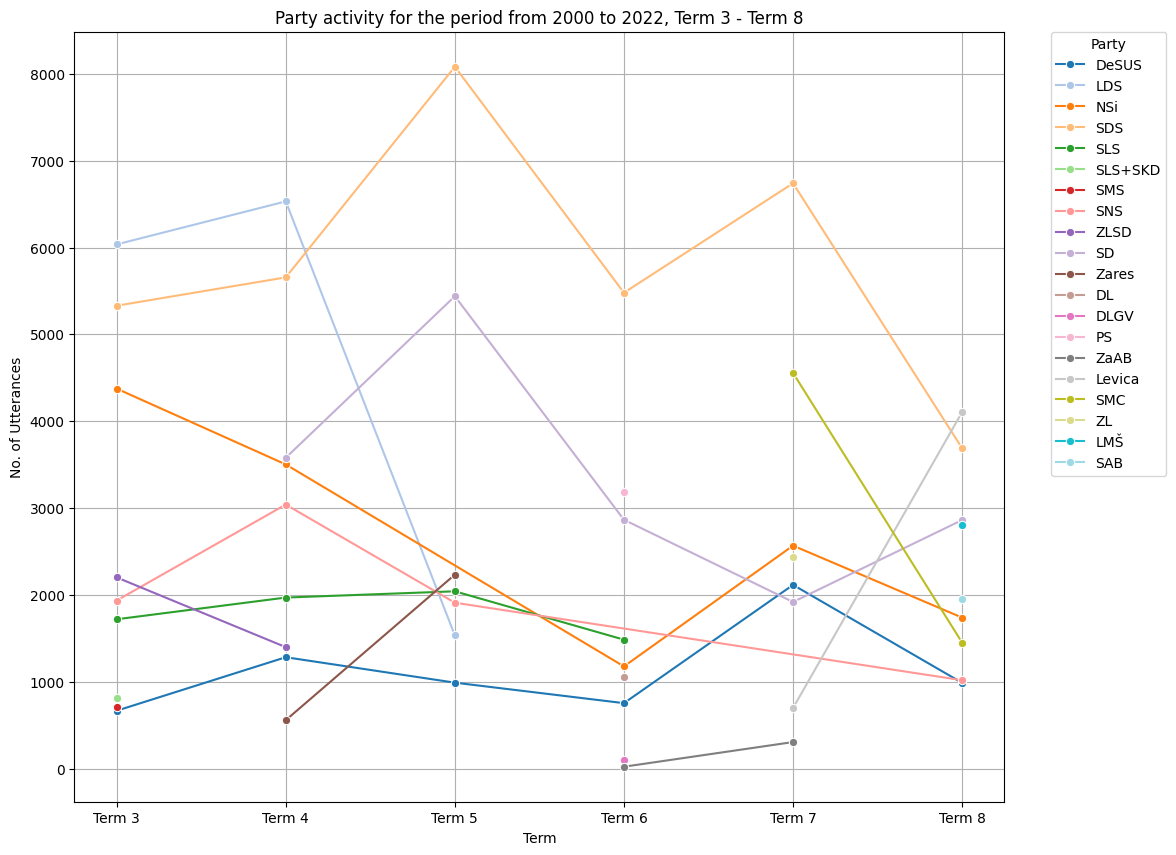

In [10]:
plt.figure(figsize=(12,10))
sns.lineplot(data=term_activity, x='Term', y='utt_count', hue='Speaker_party', marker='o', palette="tab20")
plt.title("Party activity for the period from 2000 to 2022, Term 3 - Term 8")
plt.xlabel("Term")
plt.ylabel("No. of Utterances")
plt.legend(title="Party", loc='upper left', bbox_to_anchor=(1.05, 1), borderaxespad=0.)
plt.grid(True)
plt.tight_layout
plt.show()

In [11]:
activity = utt_filter.groupby(['Term', 'Speaker_party']).agg(
    Start_year=('Year', 'min'),
    End_year=('Year', 'max'),
    Utt_count=('Year', 'size')  # Number of rows in the group
).reset_index()
activity = activity[~activity['Speaker_party'].isin(["-", "NeP", "NP", "Lipa", "Konkretno"])]
activity.head()

,Term,Speaker_party,Start_year,End_year,Utt_count
1,Term 3,DeSUS,2000,2004,666
2,Term 3,LDS,2000,2004,6036
3,Term 3,NSi,2000,2004,4375
5,Term 3,SDS,2000,2004,5330
6,Term 3,SLS,2002,2004,1719


In [40]:
import plotly.express as px
from PIL import Image

fig = px.timeline(
    activity,
    x_start="Start_year",
    x_end="End_year",
    y="Speaker_party",
    color="Utt_count",
    title="Party Activity Across Terms (Gantt Chart)",
    labels={"utt_count": "Utterance Count"}
)
fig.update_layout(
    height=600  # Set the height to your desired value
)
fig.write_html("../../Figures/Sentiment_Analysis/Parties/Party_activity_Gantt.html")
#fig.write_image("../../Figures/Sentiment_Analysis/Parties/Party_activity_Gantt.png")

#img = Image.open("../../Figures/Sentiment_Analysis/Parties/Party_activity_Gantt.png")
#img.save("../../Figures/Sentiment_Analysis/Parties/Party_activity_Gantt.pdf", "PDF")

fig.show()


## Checking label distribution (without procedural speech)

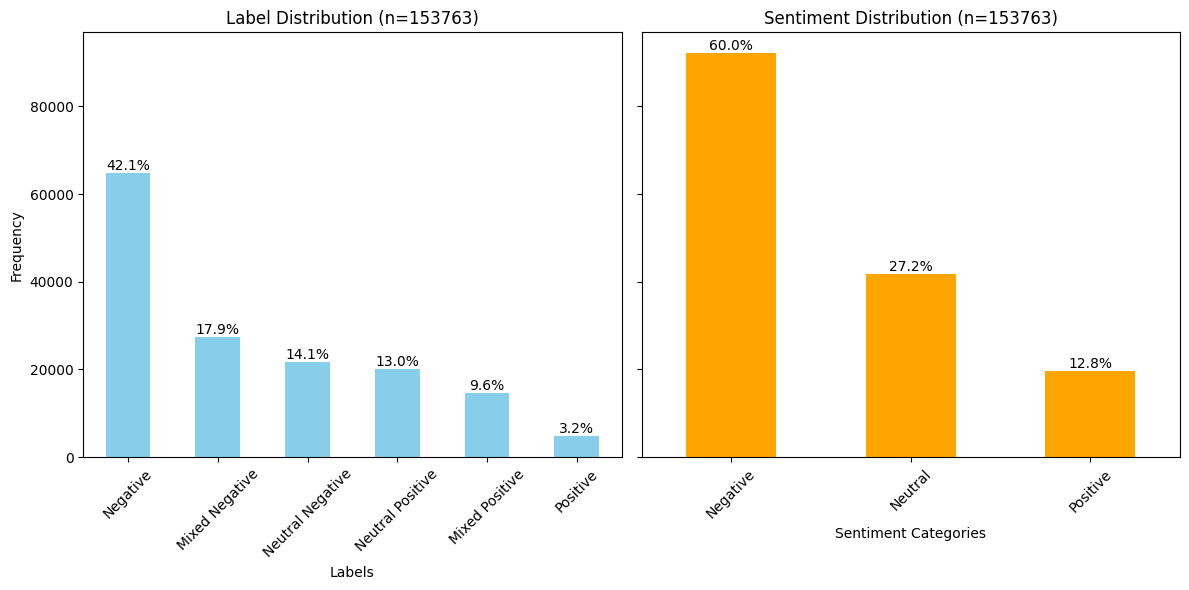

In [13]:
def add_percentage(ax, counts):
    total = counts.sum()
    for p in ax.patches:
        percentage = f"{(p.get_height() / total) * 100:.1f}%"
        ax.annotate(percentage,  (p.get_x() + p.get_width() / 2, p.get_height()), 
                    ha='center', va='bottom', fontsize=10, color='black')

fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharey=True)
utt_labels.plot(kind='bar', ax=axes[0], color = 'skyblue')
axes[0].set_title('Label Distribution (n=153763)')
axes[0].set_xlabel('Labels')
axes[0].set_ylabel('Frequency')
axes[0].tick_params(axis='x', rotation=45)
add_percentage(axes[0], utt_labels)

utt_sentiment.plot(kind='bar', ax=axes[1], color='orange')
axes[1].set_title('Sentiment Distribution (n=153763)')
axes[1].set_xlabel('Sentiment Categories')
axes[1].tick_params(axis='x', rotation=45)
add_percentage(axes[1], utt_sentiment)

plt.tight_layout()
plt.savefig('../../Figures/Sentiment_Analysis/Sentiment_distribution.png', dpi=300)
plt.show()

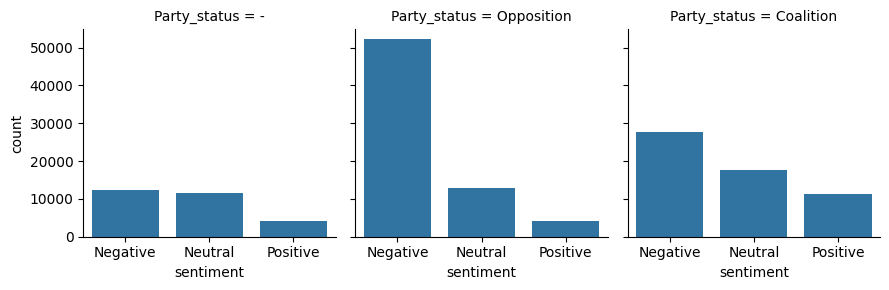

In [14]:
g = sns.FacetGrid(utt_filter, col="Party_status", margin_titles=True)
g.map(sns.countplot, "sentiment", order=["Negative", "Neutral", "Positive"])
#plt.savefig('../../Figures/Sentiment_Analysis/Sentiment_per_Party_status.png', dpi=300)
plt.show()

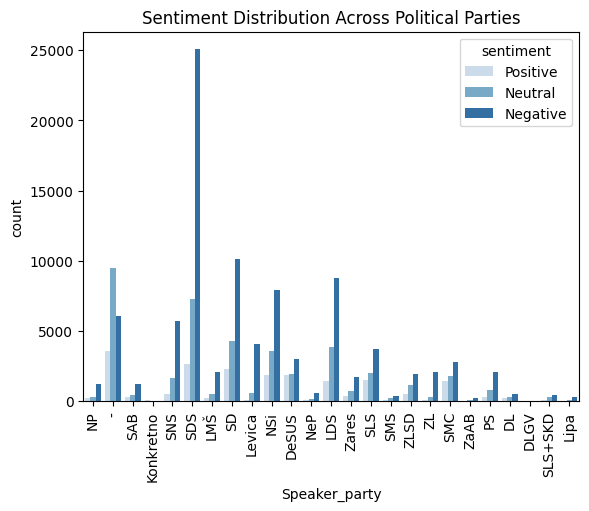

In [15]:
sns.countplot(data=utt_filter, x='Speaker_party', hue='sentiment', order=utt_filter['Speaker_party'].unique(), palette='Blues')
plt.xticks(rotation=90)
plt.title('Sentiment Distribution Across Political Parties')
plt.savefig('../../Figures/Sentiment_Analysis/Sentiment_per_Political_parties.png', dpi=300)

plt.show()

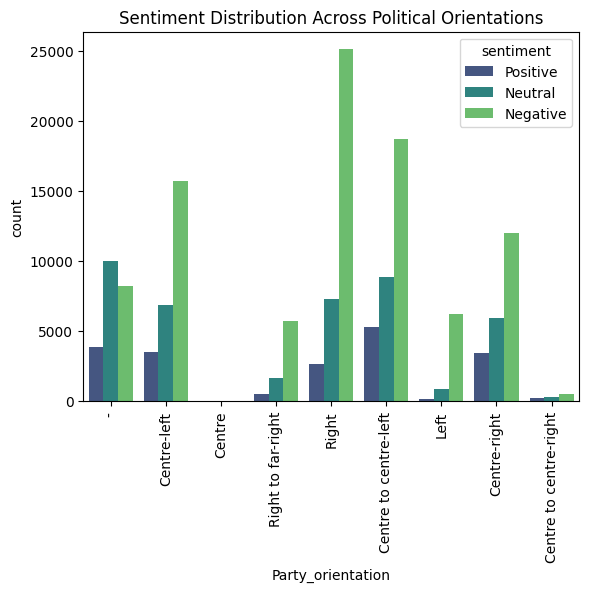

In [16]:
sns.countplot(data=utt_filter, x='Party_orientation', hue='sentiment', order=utt_filter['Party_orientation'].unique(), palette='viridis')
plt.xticks(rotation=90)
plt.title('Sentiment Distribution Across Political Orientations')
plt.savefig('../../Figures/Sentiment_Analysis/Sentiment_per_Orientation.png', dpi=300)

plt.show()

## Percentage of Negative speeches per individual party/political orientation/party status
Different visualizations & checking percentage of negative speeches to get a better interpretations of the data


### Political parties

In [17]:
pivot_parties = pd.crosstab(utt_filter['Speaker_party'], utt_filter['sentiment'])
pivot_parties = pivot_parties.loc[pivot_parties.index != '-']

pivot_parties['Total'] = pivot_parties.sum(axis=1)
pivot_parties['% Negative'] = (pivot_parties['Negative'] / pivot_parties['Total']) * 100
pivot_parties['% Neutral'] = (pivot_parties['Neutral'] / pivot_parties['Total']) * 100
pivot_parties['% Positive'] = (pivot_parties['Positive'] / pivot_parties['Total']) * 100


pivot_parties['% Negative'] = pivot_parties['% Negative'].round(2)
pivot_parties['% Neutral'] = pivot_parties['% Neutral'].round(2)
pivot_parties['% Positive'] = pivot_parties['% Positive'].round(2)


pivot_parties

sentiment,Negative,Neutral,Positive,Total,% Negative,% Neutral,% Positive
Speaker_party,,,,,,,
DL,537,297,219,1053,51.00,28.21,20.80
DLGV,34,20,39,93,36.56,21.51,41.94
DeSUS,2985,1929,1878,6792,43.95,28.40,27.65
Konkretno,28,33,54,115,24.35,28.70,46.96
LDS,8790,3851,1459,14100,62.34,27.31,10.35
LMŠ,2055,519,236,2810,73.13,18.47,8.40
Levica,4099,592,111,4802,85.36,12.33,2.31
Lipa,304,75,16,395,76.96,18.99,4.05
NP,1213,274,201,1688,71.86,16.23,11.91


In [18]:
#print(pivot_parties.to_latex(multirow = True))

#### Percentages of Negative/Positive or Neutral speeches by parties

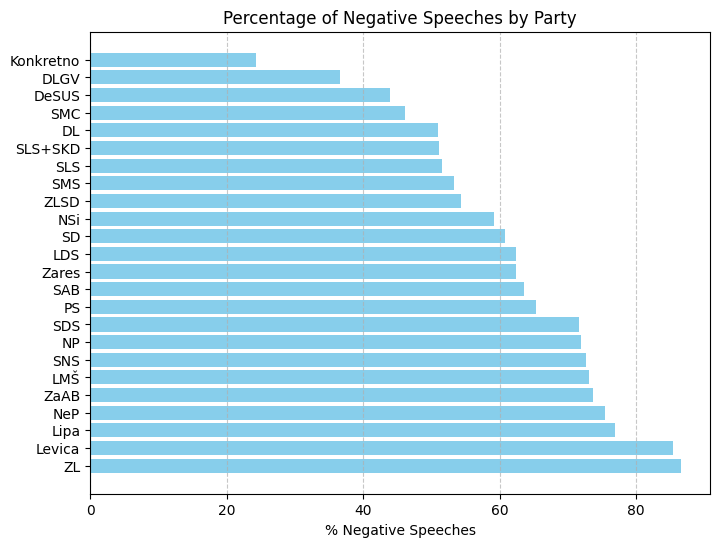

In [19]:
parties_negative = pivot_parties.sort_values('% Negative', ascending=False)

plt.figure(figsize=(8, 6))
plt.barh(parties_negative.index, parties_negative['% Negative'], color='skyblue')
plt.xlabel('% Negative Speeches')
plt.title('Percentage of Negative Speeches by Party')
plt.grid(axis='x', linestyle='--', alpha=0.7)
#plt.savefig('../../Figures/Sentiment_Analysis/Parties/Negative_Speech_by_Party.png', dpi=300)

plt.show()

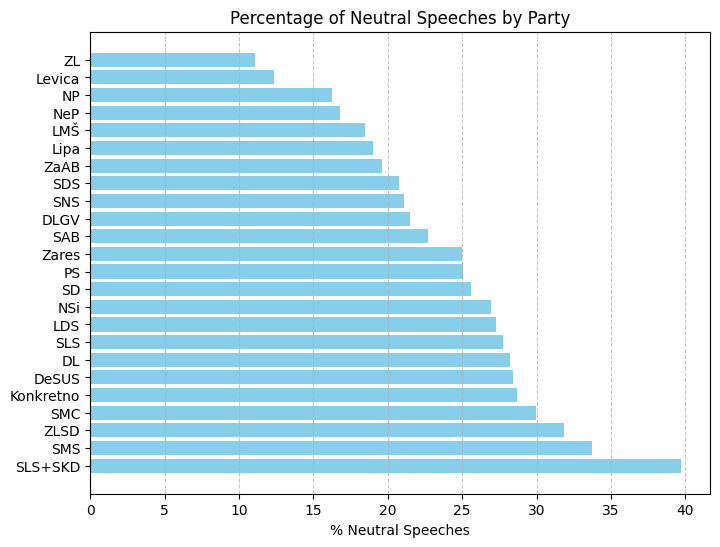

In [20]:
parties_neutral = pivot_parties.sort_values('% Neutral', ascending=False)

plt.figure(figsize=(8, 6))
plt.barh(parties_neutral.index, parties_neutral['% Neutral'], color='skyblue')
plt.xlabel('% Neutral Speeches')
plt.title('Percentage of Neutral Speeches by Party')
plt.grid(axis='x', linestyle='--', alpha=0.7)
#plt.savefig('../../Figures/Sentiment_Analysis/Parties/Netrual_Speech_by_Party.png', dpi=300)

plt.show()

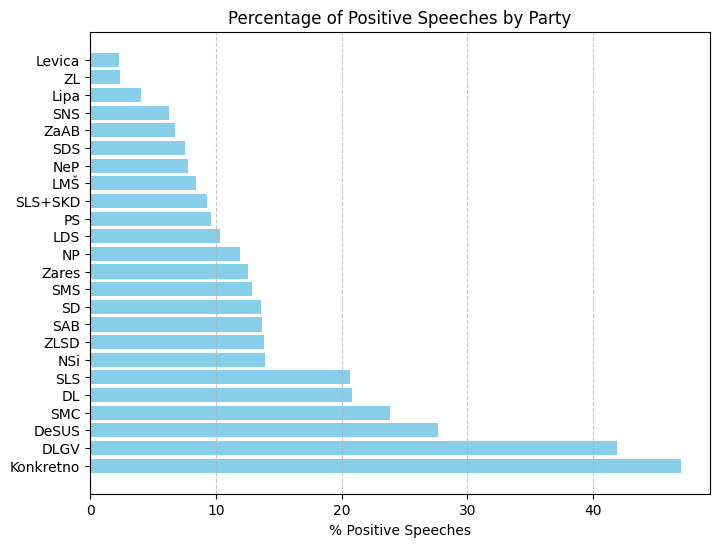

In [21]:
parties_positive = pivot_parties.sort_values('% Positive', ascending=False)

plt.figure(figsize=(8, 6))
plt.barh(parties_positive.index, parties_positive['% Positive'], color='skyblue')
plt.xlabel('% Positive Speeches')
plt.title('Percentage of Positive Speeches by Party')
plt.grid(axis='x', linestyle='--', alpha=0.7)
#plt.savefig('../../Figures/Sentiment_Analysis/Parties/Positive_Speech_by_Party.png', dpi=300)

plt.show()

Combining all of the above graphs into one visualisation for better interpretation

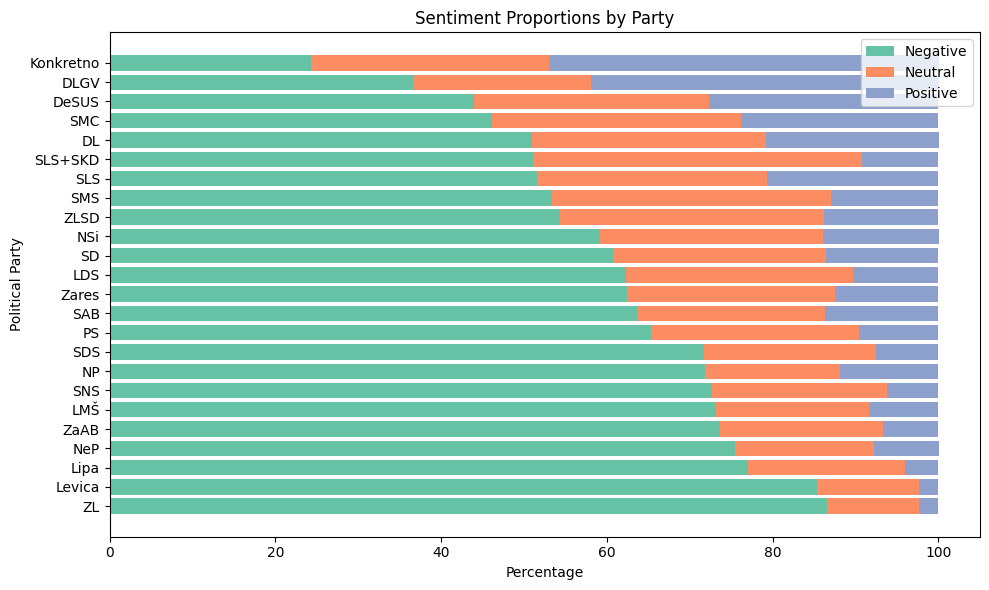

In [22]:
palette = sns.color_palette("Set2", 3)
pivot_parties = pivot_parties.sort_values(by='% Negative', ascending=False)


fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(pivot_parties.index, pivot_parties['% Negative'], label='Negative',  color=palette[0])
ax.barh(pivot_parties.index, pivot_parties['% Neutral'], label='Neutral', left=pivot_parties['% Negative'], color=palette[1])
ax.barh(pivot_parties.index, pivot_parties['% Positive'], left=pivot_parties['% Negative'] + pivot_parties['% Neutral'], label='Positive', color=palette[2])

ax.set_ylabel('Political Party')
ax.set_xlabel('Percentage')
ax.set_title('Sentiment Proportions by Party')
ax.legend()

plt.tight_layout()
plt.savefig('../../Figures/Sentiment_Analysis/Parties/Party_Sentiment_proportions.png', dpi=300)
plt.show()

### Political orientations

In [23]:
pivot_orientation = pd.crosstab(utt_filter['Party_orientation'], utt_filter['sentiment'])
pivot_orientation = pivot_orientation.loc[pivot_orientation.index != '-']

pivot_orientation['Total'] = pivot_orientation.sum(axis=1)
pivot_orientation['% Negative'] = (pivot_orientation['Negative'] / pivot_orientation['Total'])*100
pivot_orientation['% Neutral'] = (pivot_orientation['Neutral'] / pivot_orientation['Total'])*100
pivot_orientation['% Positive'] = (pivot_orientation['Positive'] / pivot_orientation['Total'])*100

pivot_orientation['% Negative'] = pivot_orientation['% Negative'].round(2)
pivot_orientation['% Neutral'] = pivot_orientation['% Neutral'].round(2)
pivot_orientation['% Positive'] = pivot_orientation['% Positive'].round(2)

pivot_orientation

sentiment,Negative,Neutral,Positive,Total,% Negative,% Neutral,% Positive
Party_orientation,,,,,,,
Centre,28,33,54,115,24.35,28.70,46.96
Centre to centre-left,18685,8898,5314,32897,56.80,27.05,16.15
Centre to centre-right,537,297,219,1053,51.00,28.21,20.80
Centre-left,15683,6858,3497,26038,60.23,26.34,13.43
Centre-right,12037,5921,3422,21380,56.30,27.69,16.01
Left,6205,862,169,7236,85.75,11.91,2.34
Right,25109,7292,2667,35068,71.60,20.79,7.61
Right to far-right,5742,1665,495,7902,72.67,21.07,6.26


In [24]:
print(pivot_orientation.to_latex(multirow=True))

\begin{tabular}{lrrrrrrr}
\toprule
sentiment & Negative & Neutral & Positive & Total & % Negative & % Neutral & % Positive \\
Party_orientation &  &  &  &  &  &  &  \\
\midrule
Centre & 28 & 33 & 54 & 115 & 24.350000 & 28.700000 & 46.960000 \\
Centre to centre-left & 18685 & 8898 & 5314 & 32897 & 56.800000 & 27.050000 & 16.150000 \\
Centre to centre-right & 537 & 297 & 219 & 1053 & 51.000000 & 28.210000 & 20.800000 \\
Centre-left & 15683 & 6858 & 3497 & 26038 & 60.230000 & 26.340000 & 13.430000 \\
Centre-right & 12037 & 5921 & 3422 & 21380 & 56.300000 & 27.690000 & 16.010000 \\
Left & 6205 & 862 & 169 & 7236 & 85.750000 & 11.910000 & 2.340000 \\
Right & 25109 & 7292 & 2667 & 35068 & 71.600000 & 20.790000 & 7.610000 \\
Right to far-right & 5742 & 1665 & 495 & 7902 & 72.670000 & 21.070000 & 6.260000 \\
\bottomrule
\end{tabular}



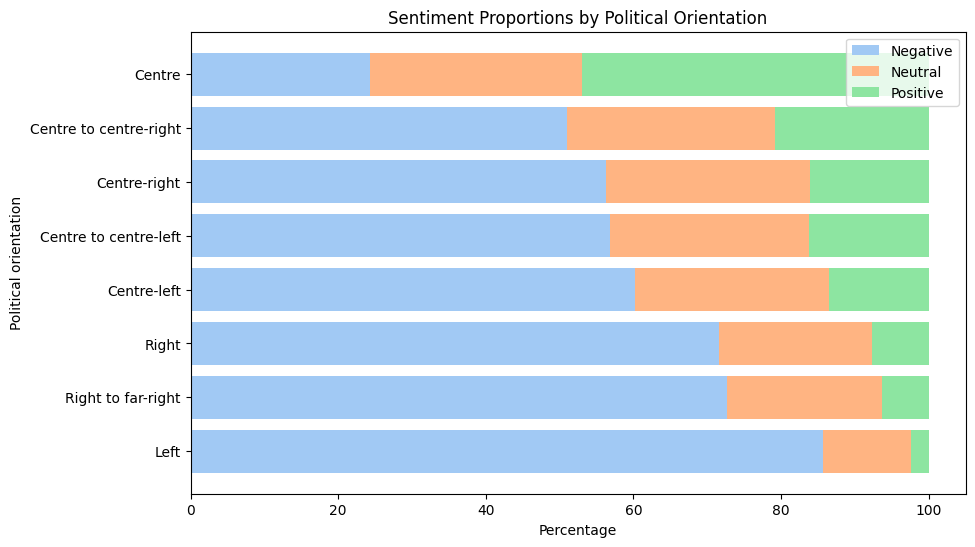

In [25]:
palette2 = sns.color_palette('pastel', 3)
pivot_orientation = pivot_orientation.sort_values(by='% Negative', ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(pivot_orientation.index, pivot_orientation['% Negative'], label='Negative', color=palette2[0])
ax.barh(pivot_orientation.index, pivot_orientation['% Neutral'], left=pivot_orientation['% Negative'], label='Neutral', color=palette2[1])
ax.barh(pivot_orientation.index, pivot_orientation['% Positive'], left=pivot_orientation['% Negative'] + pivot_orientation['% Neutral'], label='Positive', color=palette2[2])

ax.set_ylabel("Political orientation")
ax.set_xlabel("Percentage")
ax.set_title("Sentiment Proportions by Political Orientation")
ax.legend()

plt.tight_layout
plt.savefig('../../Figures/Sentiment_Analysis/Orientation/Orientation_Sentiment_proportions.png', dpi=300)
plt.show()

### Political status

In [26]:
pivot_status = pd.crosstab(utt_filter['Party_status'], utt_filter['sentiment'])
pivot_status = pivot_status.loc[pivot_status.index != '-']

pivot_status['Total'] = pivot_status.sum(axis=1)
pivot_status['% Negative'] = (pivot_status['Negative'] / pivot_status['Total'])*100
pivot_status['% Neutral'] = (pivot_status['Neutral'] / pivot_status['Total'])*100
pivot_status['% Positive'] = (pivot_status['Positive'] / pivot_status['Total'])*100

pivot_status['% Negative'] = pivot_status['% Negative'].round(2)
pivot_status['% Neutral'] = pivot_status['% Neutral'].round(2)
pivot_status['% Positive'] = pivot_status['% Positive'].round(2)

pivot_status

sentiment,Negative,Neutral,Positive,Total,% Negative,% Neutral,% Positive
Party_status,,,,,,,
Coalition,27747,17548,11365,56660,48.97,30.97,20.06
Opposition,52201,12841,4114,69156,75.48,18.57,5.95


In [27]:
print(pivot_status.to_latex(multirow=True))

\begin{tabular}{lrrrrrrr}
\toprule
sentiment & Negative & Neutral & Positive & Total & % Negative & % Neutral & % Positive \\
Party_status &  &  &  &  &  &  &  \\
\midrule
Coalition & 27747 & 17548 & 11365 & 56660 & 48.970000 & 30.970000 & 20.060000 \\
Opposition & 52201 & 12841 & 4114 & 69156 & 75.480000 & 18.570000 & 5.950000 \\
\bottomrule
\end{tabular}



### Term

In [28]:
pivot_term = pd.crosstab(utt_filter['Term'], utt_filter['sentiment'])
pivot_term = pivot_term.loc[pivot_term.index != '-']

pivot_term['Total'] = pivot_term.sum(axis=1)
pivot_term['% Negative'] = (pivot_term['Negative'] / pivot_term['Total'])*100
pivot_term['% Neutral'] = (pivot_term['Neutral'] / pivot_term['Total'])*100
pivot_term['% Positive'] = (pivot_term['Positive'] / pivot_term['Total'])*100

pivot_term['% Negative'] = pivot_term['% Negative'].round(2)
pivot_term['% Neutral'] = pivot_term['% Neutral'].round(2)
pivot_term['% Positive'] = pivot_term['% Positive'].round(2)

pivot_term

sentiment,Negative,Neutral,Positive,Total,% Negative,% Neutral,% Positive
Term,,,,,,,
Term 3,15380,9561,2528,27469,55.99,34.81,9.20
Term 4,18588,8515,4251,31354,59.28,27.16,13.56
Term 5,15101,6880,3290,25271,59.76,27.22,13.02
Term 6,11496,4608,2373,18477,62.22,24.94,12.84
Term 7,16078,6205,3612,25895,62.09,23.96,13.95
Term 8,15616,6045,3636,25297,61.73,23.90,14.37


In [29]:
print(pivot_term.to_latex(multirow=True))

\begin{tabular}{lrrrrrrr}
\toprule
sentiment & Negative & Neutral & Positive & Total & % Negative & % Neutral & % Positive \\
Term &  &  &  &  &  &  &  \\
\midrule
Term 3 & 15380 & 9561 & 2528 & 27469 & 55.990000 & 34.810000 & 9.200000 \\
Term 4 & 18588 & 8515 & 4251 & 31354 & 59.280000 & 27.160000 & 13.560000 \\
Term 5 & 15101 & 6880 & 3290 & 25271 & 59.760000 & 27.220000 & 13.020000 \\
Term 6 & 11496 & 4608 & 2373 & 18477 & 62.220000 & 24.940000 & 12.840000 \\
Term 7 & 16078 & 6205 & 3612 & 25895 & 62.090000 & 23.960000 & 13.950000 \\
Term 8 & 15616 & 6045 & 3636 & 25297 & 61.730000 & 23.900000 & 14.370000 \\
\bottomrule
\end{tabular}



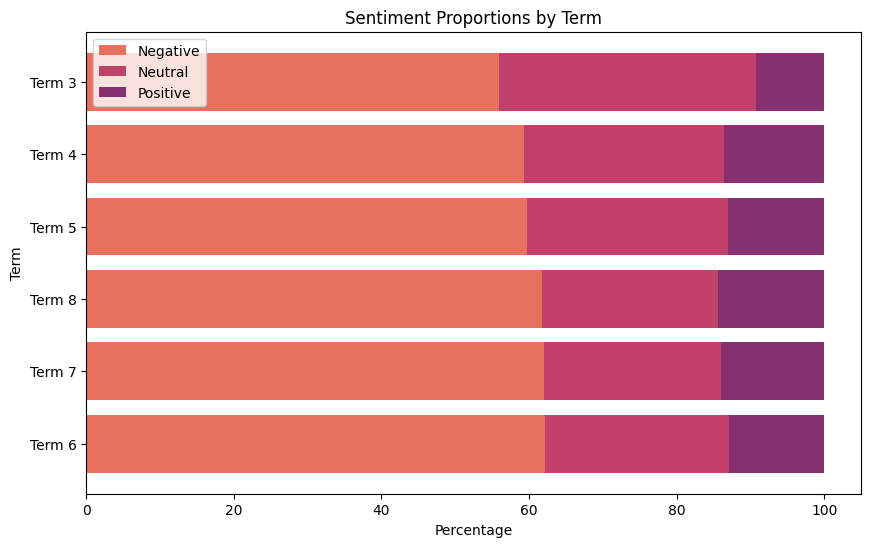

In [30]:
palette3 = sns.color_palette('flare', 3)
pivot_term = pivot_term.sort_values(by='% Negative', ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(pivot_term.index, pivot_term['% Negative'], label='Negative', color=palette3[0])
ax.barh(pivot_term.index, pivot_term['% Neutral'], left=pivot_term['% Negative'], label='Neutral', color=palette3[1])
ax.barh(pivot_term.index, pivot_term['% Positive'], left=pivot_term['% Negative'] + pivot_term['% Neutral'], label='Positive', color=palette3[2])

ax.set_ylabel("Term")
ax.set_xlabel("Percentage")
ax.set_title("Sentiment Proportions by Term")
ax.legend()

plt.tight_layout
plt.savefig('../../Figures/Sentiment_Analysis/Terms/Term_Sentiment_proportions.png', dpi=300)
plt.show()

## Checking sentiment across terms

In [31]:
mandates = utt_filter[['ID', 'Term', 'Date', 'Year', 'utt_annotations', 'labels', 'sentiment', 'Speaker_party', 'Party_status', 'Party_orientation']]
mandates

,ID,Term,Date,Year,utt_annotations,labels,sentiment,Speaker_party,Party_status,Party_orientation
1,ParlaMint-SI_2022-04-06-SDZ8-Izredna-99.ana.u2,Term 8,2022-04-06,2022,3.88,Mixed Positive,Positive,NP,-,-
3,ParlaMint-SI_2022-04-06-SDZ8-Izredna-99.ana.u4,Term 8,2022-04-06,2022,3.19,Neutral Positive,Neutral,-,-,-
5,ParlaMint-SI_2022-04-06-SDZ8-Izredna-99.ana.u6,Term 8,2022-04-06,2022,4.38,Mixed Positive,Positive,SAB,Opposition,Centre-left
7,ParlaMint-SI_2022-04-06-SDZ8-Izredna-99.ana.u8,Term 8,2022-04-06,2022,3.94,Mixed Positive,Positive,Konkretno,Coalition,Centre
9,ParlaMint-SI_2022-04-06-SDZ8-Izredna-99.ana.u10,Term 8,2022-04-06,2022,4.92,Positive,Positive,SNS,Opposition,Right to far-right
...,...,...,...,...,...,...,...,...,...,...
311337,ParlaMint-SI_2005-01-24-SDZ4-Redna-02.ana.u237,Term 4,2005-01-24,2005,1.88,Neutral Negative,Neutral,NSi,Coalition,Centre-right
311339,ParlaMint-SI_2005-01-24-SDZ4-Redna-02.ana.u239,Term 4,2005-01-24,2005,2.52,Neutral Positive,Neutral,LDS,Opposition,Centre to centre-left
311341,ParlaMint-SI_2005-01-24-SDZ4-Redna-02.ana.u241,Term 4,2005-01-24,2005,1.49,Mixed Negative,Negative,LDS,Opposition,Centre to centre-left
311343,ParlaMint-SI_2005-01-24-SDZ4-Redna-02.ana.u243,Term 4,2005-01-24,2005,2.75,Neutral Positive,Neutral,LDS,Opposition,Centre to centre-left


In [32]:
import numpy as np
#Droping the utterances, where the speakers are not affiliated with political parties
mandates.replace('-', np.nan, inplace=True)
print(len(mandates))

terms = mandates.copy()
terms['utt_annotations'] = pd.to_numeric(terms['utt_annotations'])
trends = terms.groupby(['Speaker_party', 'Term']).agg({'utt_annotations':'mean'}).reset_index()
trends['Term'] = pd.Categorical(trends['Term'], ordered=True)

trends


153763


/var/folders/l_/t5l44v1s7d9168_x8bm5ly0h0000gn/T/ipykernel_2009/487359668.py:3: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



,Speaker_party,Term,utt_annotations
0,DL,Term 6,1.827236
1,DLGV,Term 6,2.553871
2,DeSUS,Term 3,2.168994
3,DeSUS,Term 4,1.860725
4,DeSUS,Term 5,2.477836
...,...,...,...
59,ZLSD,Term 4,1.063720
60,ZaAB,Term 6,1.994286
61,ZaAB,Term 7,0.892525
62,Zares,Term 4,0.711831


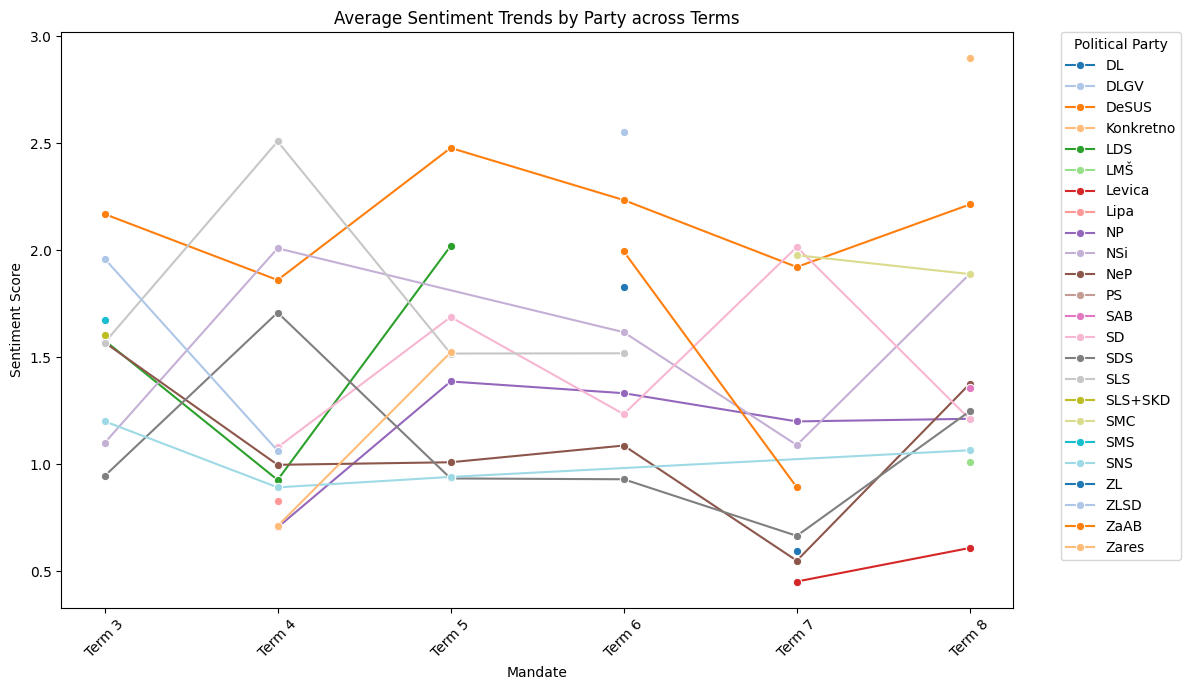

In [33]:
plt.figure(figsize=(12, 7))
sns.lineplot(data=trends, x='Term', y='utt_annotations', hue='Speaker_party', marker='o', linewidth=1.5, palette='tab20')

plt.title('Average Sentiment Trends by Party across Terms')
plt.xlabel('Mandate')
plt.ylabel('Sentiment Score')
plt.legend(title='Political Party', loc='upper left', bbox_to_anchor=(1.05, 1), borderaxespad=0.)
plt.xticks(rotation=45)
plt.savefig('../../Figures/Sentiment_Analysis/Sentiment_Trends.png', dpi=300)

plt.tight_layout()



## Checking sentiment trends within each term

In [34]:
government = pd.DataFrame({
    'Government': ['Gov5', 'Gov6', 'Gov7', 'Gov8', 'Gov9', 'Gov10', 'Gov11', 'Gov12', 'Gov13', 'Gov14'],
    'Start_Date': ['2000-06-07', '2000-12-01', '2002-12-20', '2004-12-04', '2008-11-22', '2012-02-11', '2013-03-21', '2014-09-19', '2018-09-14', '2020-03-14'],
    'End_Date': ['2000-11-30', '2002-12-19', '2004-12-03', '2008-11-21', '2012-02-10', '2013-03-20', '2014-09-18', '2018-09-13', '2020-03-13', '2022-06-01']
})

government['Start_Date'] = pd.to_datetime(government['Start_Date'])
government['End_Date'] = pd.to_datetime(government['End_Date'])
government
terms['Date'] = pd.to_datetime(terms['Date'])

def map_government(date):
    for _, row in government.iterrows():
        if row['Start_Date'] <= date <= row['End_Date']:
            return row['Government']
    return None

# Apply the function to add a new column
terms['Government'] = terms['Date'].apply(map_government)

terms

,ID,Term,Date,Year,utt_annotations,labels,sentiment,Speaker_party,Party_status,Party_orientation,Government
1,ParlaMint-SI_2022-04-06-SDZ8-Izredna-99.ana.u2,Term 8,2022-04-06,2022,3.88,Mixed Positive,Positive,NP,NaN,NaN,Gov14
3,ParlaMint-SI_2022-04-06-SDZ8-Izredna-99.ana.u4,Term 8,2022-04-06,2022,3.19,Neutral Positive,Neutral,NaN,NaN,NaN,Gov14
5,ParlaMint-SI_2022-04-06-SDZ8-Izredna-99.ana.u6,Term 8,2022-04-06,2022,4.38,Mixed Positive,Positive,SAB,Opposition,Centre-left,Gov14
7,ParlaMint-SI_2022-04-06-SDZ8-Izredna-99.ana.u8,Term 8,2022-04-06,2022,3.94,Mixed Positive,Positive,Konkretno,Coalition,Centre,Gov14
9,ParlaMint-SI_2022-04-06-SDZ8-Izredna-99.ana.u10,Term 8,2022-04-06,2022,4.92,Positive,Positive,SNS,Opposition,Right to far-right,Gov14
...,...,...,...,...,...,...,...,...,...,...,...
311337,ParlaMint-SI_2005-01-24-SDZ4-Redna-02.ana.u237,Term 4,2005-01-24,2005,1.88,Neutral Negative,Neutral,NSi,Coalition,Centre-right,Gov8
311339,ParlaMint-SI_2005-01-24-SDZ4-Redna-02.ana.u239,Term 4,2005-01-24,2005,2.52,Neutral Positive,Neutral,LDS,Opposition,Centre to centre-left,Gov8
311341,ParlaMint-SI_2005-01-24-SDZ4-Redna-02.ana.u241,Term 4,2005-01-24,2005,1.49,Mixed Negative,Negative,LDS,Opposition,Centre to centre-left,Gov8
311343,ParlaMint-SI_2005-01-24-SDZ4-Redna-02.ana.u243,Term 4,2005-01-24,2005,2.75,Neutral Positive,Neutral,LDS,Opposition,Centre to centre-left,Gov8


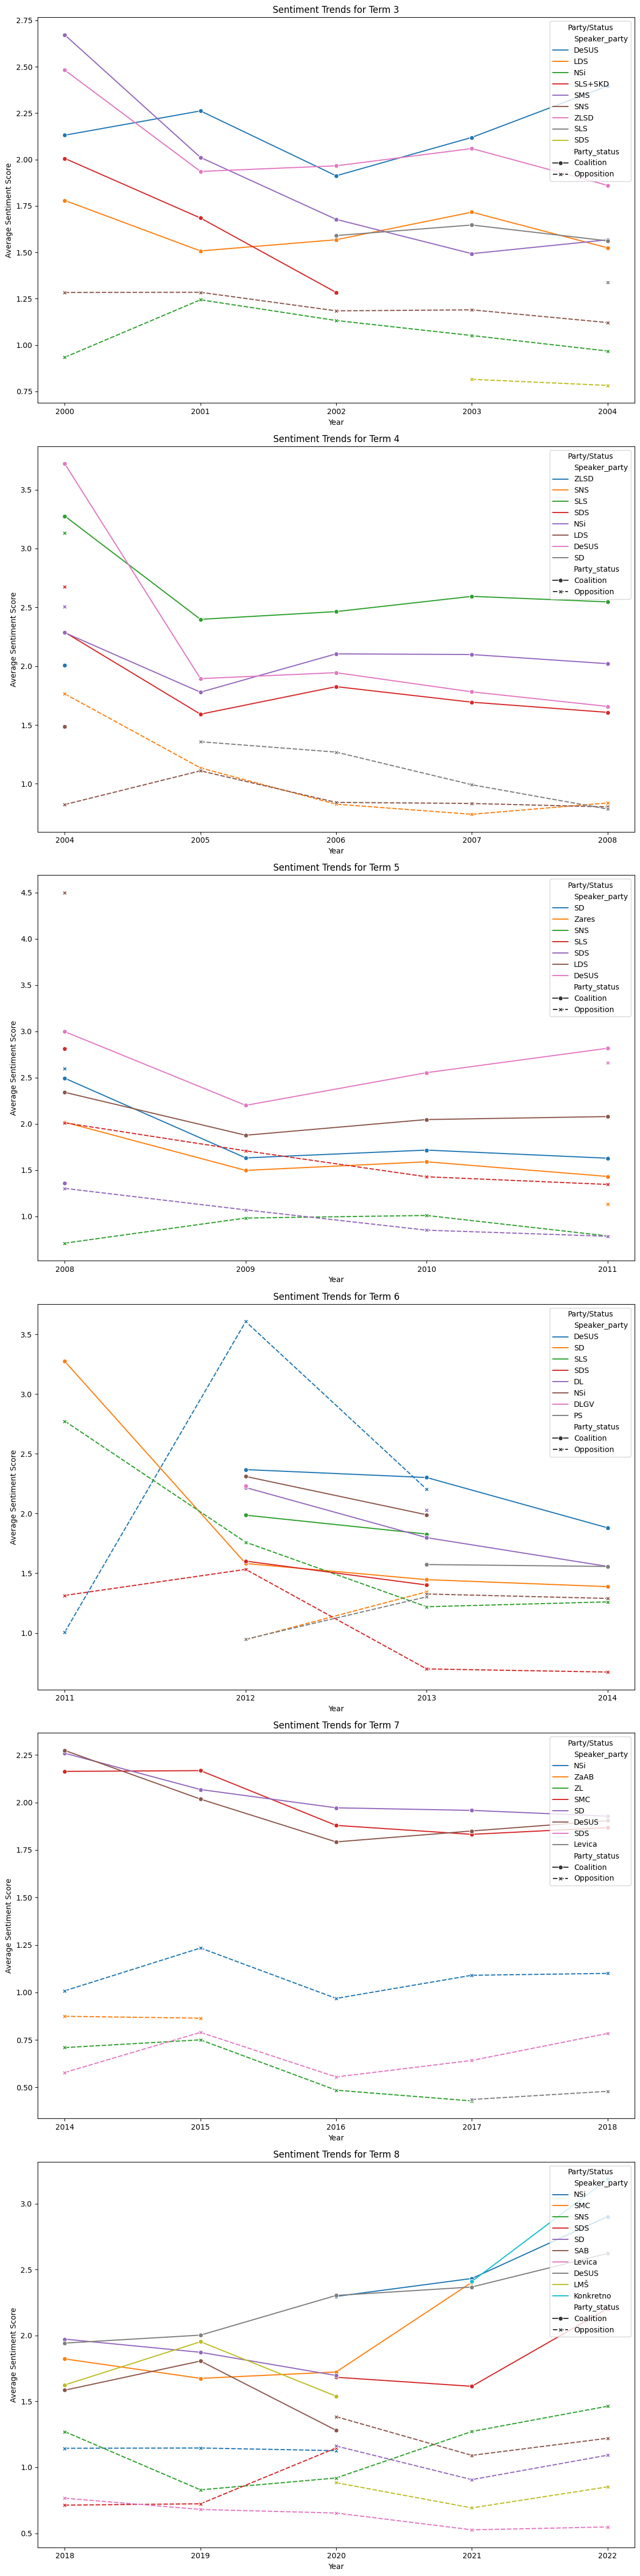

In [35]:
term_sent = terms.groupby(['Term', 'Year', 'Speaker_party', 'Party_status']).agg({'utt_annotations':'mean'}).reset_index()
term_sent['Party_status'] = term_sent['Party_status'].astype('category')
term_sent = term_sent.sort_values(by='Year', ascending=True)

## Giving each individual political party a colour to be tracked throughout the subplots (not distinctive enough)
#unique_parties = term_sent['Speaker_party'].unique()
#party_palette = sns.color_palette("Set2", n_colors=len(unique_parties))
#party_color_mapping = {party: party_palette[i] for i, party in enumerate(unique_parties)}


n_terms = term_sent['Term'].unique()


fig, axes = plt.subplots(len(n_terms), 1, figsize=(12, 8 * len(n_terms)))

for i, term in enumerate(n_terms):
    ax = axes[i] if len(n_terms) > 1 else axes
    term_data = term_sent[term_sent['Term'] == term]

    sns.lineplot(data=term_data, x='Year', y='utt_annotations', hue='Speaker_party', style='Party_status' , ax=ax, markers=True)
    ax.set_title(f"Sentiment Trends for {term}")
    ax.set_xlabel('Year')
    ax.set_ylabel('Average Sentiment Score')
    ax.legend(title='Party/Status', loc='upper right')

plt.tight_layout()
plt.savefig('../../Figures/Sentiment_Analysis/Sentiment_for_Terms.png', dpi=300)

plt.show()



Interpretation of the trends witih individual mandate:

-Term 6: The overlap between the coalition and opposition values for certain political parties is due to the fact that there is a change in the government - Term 6 observes multiple government structures in its duration, namely: 
- 9. Vlada Republike Slovenije (21. 11. 2008 - 10. 2. 2012)
predsednik vlade Borut Pahor
- 10. Vlada Republike Slovenije (10. 2. 2012 - 20. 3. 2013)
predsednik vlade Janez Janša
- 11. Vlada Republike Slovenije (20. 3. 2013 - 18. 9. 2014)
predsednica vlade mag. Alenka Bratušek



In [36]:
###Generating individual plots for a paper/chapter
for term in n_terms:
    term_data = term_sent[term_sent['Term'] == term]
    
    plt.figure(figsize=(12, 8))
    
    sns.lineplot(data=term_data, x='Year', y='utt_annotations', hue='Speaker_party',
                 style='Party_status', markers=True)
    
    plt.title(f"Sentiment Trends for {term}")
    plt.xlabel('Year')
    plt.ylabel('Average Sentiment Score')
    plt.legend(title='Party/Status', loc='upper right')
    
    plt.tight_layout()
    plt.savefig(f'../../Figures/Sentiment_Analysis/Terms/Sentiment_{term}.png', dpi=300)
    
    plt.close()

In [37]:
term_sent.to_csv('../../Tables/Terms.csv', encoding='utf-8', index=False)

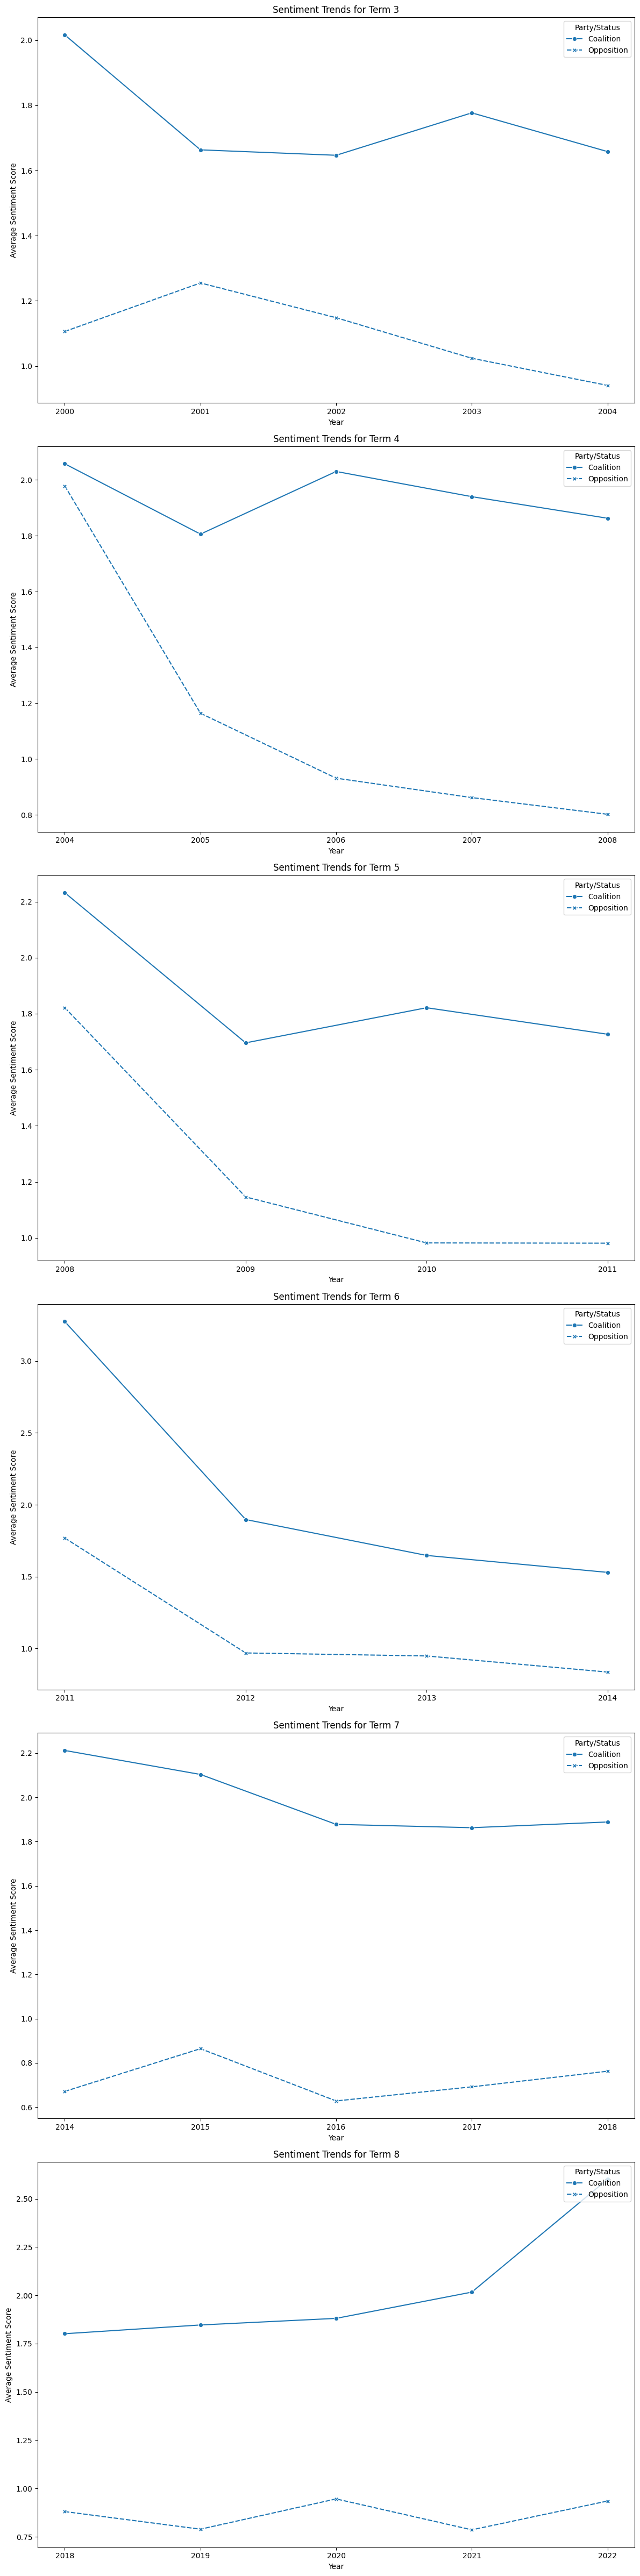

In [38]:
status = terms.groupby(['Term', 'Year', 'Party_status']).agg({'utt_annotations':'mean'}).reset_index()
status['Party_status'] = status['Party_status'].astype('category')
status = status.sort_values(by='Year', ascending=True)

## Giving each individual political party a colour to be tracked throughout the subplots (not distinctive enough)
#unique_parties = term_sent['Speaker_party'].unique()
#party_palette = sns.color_palette("Set2", n_colors=len(unique_parties))
#party_color_mapping = {party: party_palette[i] for i, party in enumerate(unique_parties)}


n_terms = status['Term'].unique()


fig, axes = plt.subplots(len(n_terms), 1, figsize=(12, 8 * len(n_terms)))

for i, term in enumerate(n_terms):
    ax = axes[i] if len(n_terms) > 1 else axes
    term_data = status[status['Term'] == term]

    sns.lineplot(data=term_data, x='Year', y='utt_annotations', style='Party_status' , ax=ax, markers=True)
    ax.set_title(f"Sentiment Trends for {term}")
    ax.set_xlabel('Year')
    ax.set_ylabel('Average Sentiment Score')
    ax.legend(title='Party/Status', loc='upper right')

plt.tight_layout()
#plt.savefig('../../Figures/Sentiment_Analysis/Sentiment_for_Terms.png', dpi=300)

plt.show()

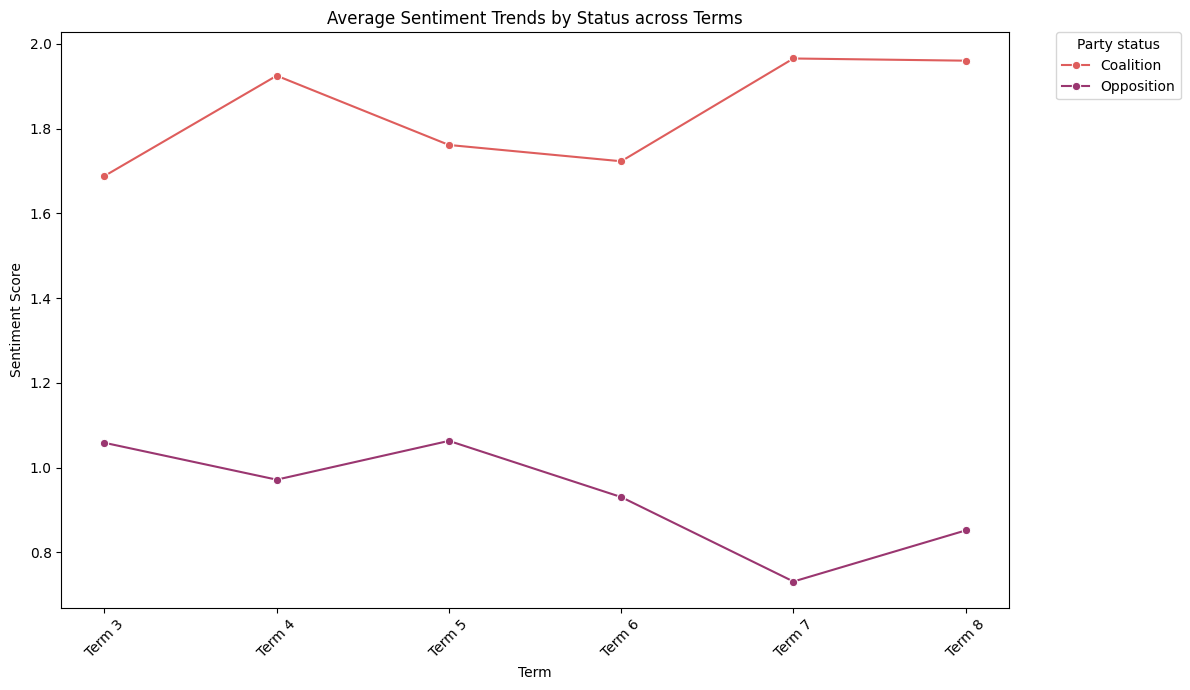

In [39]:
terms_status = mandates.copy()
terms_status['utt_annotations'] = pd.to_numeric(terms_status['utt_annotations'])
trends_status = terms_status.groupby(['Party_status', 'Term']).agg({'utt_annotations':'mean'}).reset_index()
trends_status['Term'] = pd.Categorical(trends_status['Term'], ordered=True)

trends_status

plt.figure(figsize=(12, 7))

sns.lineplot(data=trends_status, x='Term', y='utt_annotations', hue='Party_status', marker='o', linewidth=1.5, palette='flare')

plt.title('Average Sentiment Trends by Status across Terms')
plt.xlabel('Term')
plt.ylabel('Sentiment Score')
plt.legend(title='Party status', loc='upper left', bbox_to_anchor=(1.05, 1), borderaxespad=0.)
plt.xticks(rotation=45)
plt.savefig('../../Figures/Sentiment_Analysis/Status_Trends.png', dpi=300)

plt.tight_layout()